# dart-event-study — 프로젝트 여정 정리

> **한 줄 요약**: DART 공시 이벤트의 정보력은 실재하지만, 정직한 조건(look-ahead 없는 타이밍 ·
> 현실적 비용 · 승자 편향 없는 유니버스 · 시도 수 보정)을 하나씩 통과시키면
> 체계적으로 수확 가능한 초과수익은 사라진다 — **이 "보정 사다리"의 정량화가 이 프로젝트의 기여다.**

이 노트북은 프로젝트 전체 스토리를 정리한 문서다. 최종 결과의 상세 수치·차트는
[report.ipynb](./report.ipynb), 설계·실측 이력은 [PLAN.md](../PLAN.md),
신뢰도 감사는 [RELIABILITY_AUDIT.md](../RELIABILITY_AUDIT.md) 참조.

| | |
|---|---|
| 유니버스 | 2019-01 기준 KOSPI 시총 상위 200 보통주 + 기간 내 상폐 11종 |
| 기간 | 2019-01-01 ~ 2024-12-31 (거래일 1,477일) |
| 이벤트 | 자사주 직접 178 · 신탁 106 / 실적공시 5,300 / 유상증자 139 → 방향성 시그널 4,650 |
| 데이터 | 공시 목록 15.7만 건, 공시 원문 5,941건, 뉴스 창 281건 — 전부 디스크 캐시 (재현 가능) |
| 코드 | 커밋 26개 (phase 단위), 유닛테스트 72개 (전부 네트워크 불필요) |

## 1. 버전 타임라인 — 무엇을 만들고, 무엇을 고쳤나

| 버전 | 내용 | 핵심 산출/발견 |
|---|---|---|
| **v1** (Phase 0~5) | uv workspace + `shared/`(가격·캘린더·백테스트 엔진) + 이벤트 3종 추출 → 시그널 → 이벤트 스터디 → 백테스트 → 리포트 | "자사주 드리프트만 비용 생존 (+5.1%/년)" — *나중에 상한 추정치로 판명* |
| **v1.1** (외부 리뷰) | 이벤트 날짜 클러스터 SE(일/월, CR1), 차트 글리프 수정, QoQ 폴백 제외(민감도 병기), 자사주 β/α 실측(β 0.49, α 비유의) | 실적 naive t 11.6 → 월클러스터 6.5 — 어닝시즌 날짜 뭉침이 naive t를 부풀림 |
| **v1.2** (신뢰도 감사) | 진단 리포트 → 8항목 보정: 상폐 처리 엔진, **2019년 기준 유니버스**, 거래세 시행일별 스케줄+수수료, BH-FDR q값, 부트스트랩+Deflated Sharpe, 서브기간, 정지일 체결 밀기, 한계 문서화 | 유일 생존 전략이 보정 사다리에서 소멸 (아래 §2) |
| **신탁 확장** | `tsstkAqTrctrCnsDecsn` 106건 — 별도 그룹으로 독립 검증 | 드리프트 재현 (+4.10%, q=.027) — 정보력 결론 강화. 신탁 H=20 (+12.2%)도 DSR 16.8%로 우연 구분 불가 |
| **감성 레이어 1단계** | 네이버 뉴스 크롤링(±1일 창) + 제목 극성 룰, 사전 등록 검정 | 관심↑→드리프트↑ 단조 패턴(모멘텀 방향)이나 비유의(p=.13), 감성 톤 무정보 |

## 2. 핵심 서사: 보정 사다리

v1의 결론("자사주 전략이 KOSPI를 이긴다")이 보정을 하나씩 통과하며 어떻게 변했는가.
자사주 직접취득 H=5 (net 연환산) 기준 — 수치 출처는 각 버전의 커밋 로그·실행 기록:

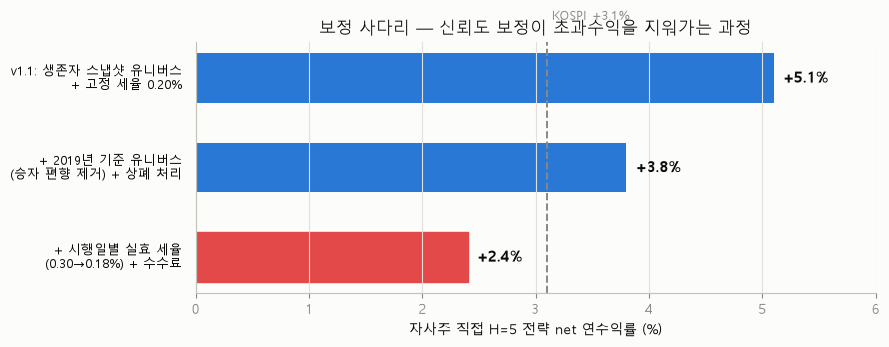

마지막 단계 이후 판정: 부트스트랩 95% CI [-0.57, +0.97], Deflated Sharpe 7% — 우연과 구분 불가.
슬리피지 민감도: 편도 0.1/0.3/0.5%에서 net +2.4% / -7.5% / -16.5% — 마진 자체가 취약.


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# dataviz 검증 팔레트 (report.ipynb와 동일 규약)
C_BLUE, C_RED, INK, MUTED, GRID, BASE = "#2a78d6", "#e34948", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid.axis": "x",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.sans-serif": ["Malgun Gothic", "DejaVu Sans"], "axes.unicode_minus": False,
})

steps = [
    ("v1.1: 생존자 스냅샷 유니버스\n+ 고정 세율 0.20%", 5.1),
    ("+ 2019년 기준 유니버스\n(승자 편향 제거) + 상폐 처리", 3.8),
    ("+ 시행일별 실효 세율\n(0.30→0.18%) + 수수료", 2.4),
]
kospi = 3.1

fig, ax = plt.subplots(figsize=(9, 3.6))
y = range(len(steps))[::-1]
vals = [v for _, v in steps]
bars = ax.barh(list(y), vals, height=0.55, color=C_BLUE)
bars[-1].set_color(C_RED)  # 최종 단계 강조 (벤치마크 하회)
for yi, (label, v) in zip(y, steps):
    ax.text(v + 0.08, yi, f"+{v:.1f}%", va="center", color=INK, fontsize=11, fontweight="bold")
    ax.text(-0.12, yi, label, va="center", ha="right", color=INK, fontsize=9.5)
ax.axvline(kospi, color=MUTED, linewidth=1.4, linestyle="--")
ax.text(kospi, len(steps) - 0.35, f" KOSPI +{kospi}%", color=MUTED, fontsize=9.5)
ax.set_yticks([])
ax.set_xlim(0, 6)
ax.set_xlabel("자사주 직접 H=5 전략 net 연수익률 (%)")
ax.set_title("보정 사다리 — 신뢰도 보정이 초과수익을 지워가는 과정", fontsize=12)
plt.tight_layout()
plt.show()

print("마지막 단계 이후 판정: 부트스트랩 95% CI [-0.57, +0.97], Deflated Sharpe 7% — 우연과 구분 불가.")
print("슬리피지 민감도: 편도 0.1/0.3/0.5%에서 net +2.4% / -7.5% / -16.5% — 마진 자체가 취약.")

## 3. 그럼에도 살아남은 것 — 정보력

백테스트(체결가능성)와 달리, **이벤트 스터디(정보력)는 모든 보정을 통과했다.**
아래는 현재 데이터에서 실시간 계산한 최종 CAR 표 (월클러스터 t + BH-FDR q<5% 기준):

In [2]:
from pathlib import Path

import pandas as pd

DATA = Path("..") / "data"
car = pd.read_parquet(DATA / "eventstudy_full" / "car_summary.parquet")
t = car.copy()
t["CAR(%)"] = (t["mean_car"] * 100).round(2)
t["t: naive→월CL"] = t["t_naive"].round(1).astype(str) + " → " + t["t_cl_month"].round(1).astype(str)
t["q_FDR"] = t["q_cl_month"].round(3)
t["판정"] = (t["q_cl_month"] < 0.05).map({True: "✓ 유의", False: "✗"})
t.loc[t["thin_sample"], "판정"] = "⚠️ 표본유보"
display(t[["event_type", "direction", "window", "N", "CAR(%)", "t: naive→월CL", "q_FDR", "판정"]]
        .rename(columns={"event_type": "이벤트", "direction": "방향", "window": "윈도우"}))
print("생존: 자사주 직접(전 윈도우) · 신탁([-1,1], [0,20]) · 실적± 공시창 · 유증- [0,+5]")
print("탈락: 실적 [0,+5] (q=6%) — 경계 유의가 다중검정 보정에서 떨어졌고, 떨어진 대로 기록.")

,이벤트,방향,윈도우,N,CAR(%),t: naive→월CL,q_FDR,판정
0,buyback,1,"[-1,1]",169,3.05,8.3 → 7.5,0.000,✓ 유의
1,buyback,1,"[0,5]",169,3.84,8.0 → 6.4,0.000,✓ 유의
2,buyback,1,"[0,20]",169,4.88,5.8 → 4.9,0.000,✓ 유의
3,buyback_trust,1,"[-1,1]",104,2.56,5.2 → 4.6,0.000,✓ 유의
4,buyback_trust,1,"[0,5]",104,2.19,2.8 → 2.2,0.060,✗
5,buyback_trust,1,"[0,20]",104,4.10,3.1 → 2.7,0.027,✓ 유의
6,earnings,-1,"[-1,1]",1767,-0.53,-4.4 → -2.6,0.027,✓ 유의
7,earnings,-1,"[0,5]",1767,-0.71,-4.5 → -2.2,0.059,✗
8,earnings,-1,"[0,20]",1767,-0.18,-0.7 → -0.3,0.801,✗
9,earnings,1,"[-1,1]",2391,1.26,11.6 → 6.9,0.000,✓ 유의


생존: 자사주 직접(전 윈도우) · 신탁([-1,1], [0,20]) · 실적± 공시창 · 유증- [0,+5]
탈락: 실적 [0,+5] (q=6%) — 경계 유의가 다중검정 보정에서 떨어졌고, 떨어진 대로 기록.


## 4. 실측으로 배운 것들 (교과서에 없는 함정)

이 프로젝트에서 문서 스펙과 실제 데이터가 달랐던 지점 — 전부 실측 후 코드/문서에 반영:

| 함정 | 실측 내용 | 대응 |
|---|---|---|
| KRX 봇차단 | 정보데이터시스템이 세션·헤더를 갖춰도 400 LOGOUT → pykrx 전체 사용 불가 | FDR(네이버) 전환, 유니버스는 프록시 시총 |
| 공시 원문 인코딩 | 2022+ 문서가 meta엔 euc-kr 선언, 실제는 utf-8 | utf-8 strict 우선 디코딩 (파싱 실패율 46%→4%) |
| 접수 '시각' 부재 | OpenDART·DART뷰어·KIND 모두 과거 공시의 HH:MM 미제공 | 전 건 익영업일 체결 보수 가정 (컷오프 로직은 내장·테스트) |
| 구형 잠정실적 | 2019~20 공시는 전년동기 칸이 비어 YoY 계산 불가 | QoQ 참고 계산하되 시그널 제외 (계절성) |
| 유니버스 승자 편향 | "현재 시총 상위"와 2019년 상위가 31% 다름 | 2019-01 기준 재구성 + 상폐 편입 — **가장 큰 보정** |
| 상폐 사유의 이질성 | 기간 내 30건 중 손실형은 5건뿐 (16건은 완전자회사화) | 손실형만 청산 할인, 합병은 무할인 청산 |
| API 장기 세션 끊김 | OpenDART 10054, 네이버 soft-403 | 재시도+백오프+세션 교체, 전 응답 디스크 캐시로 재개 가능 |
| 통계 부풀림 | 어닝시즌 날짜 뭉침, 15~18개 동시 검정, 20개 조합 시도 | 클러스터 SE + FDR q + Deflated Sharpe — 셋 다 병기 |

## 5. 파이프라인 구조 (재현 관점)

```
shared/quantlab_shared/            ← 재사용 인프라 (다음 프로젝트용)
├── data/      가격 로더(FDR)·영업일 캘린더·유니버스(2019 프록시+상폐)
└── backtest/  엔진(균등가중·|Δw| 비용·상폐/정지 처리)·비용모델(세율 스케줄)·성과지표

projects/dart-event-study/src/dart_event_study/
├── dart/       OpenDART 클라이언트 (스로틀·재시도·디스크 캐시)
├── events/     자사주(직접/신탁)·유증·실적 추출 — 구조화 API 우선, 원문 파싱 보완
├── signals/    접수일 → 체결가능일 매핑 (look-ahead 방지, 타이밍 테스트)
├── sentiment/  뉴스 크롤러 + 극성어 사전 룰
└── analysis/   이벤트 스터디(클러스터 t·FDR)·백테스트·유의성(부트스트랩·DSR)·attention

실행 순서: collect → events.extract → signals.build
         → analysis.{event_study, backtest, significance}
         → sentiment.collect → analysis.attention          (각 단계 캐시·재개 가능)
```

## 6. 남은 것 (+α — 코어는 완결)

- 감성 심화: 뉴스 댓글 → 종목토론방 (날것 반응), 룰 한계 확인 시 모델 감성
- 접수시각 소스 확보 시 당일 체결 변형 백테스트 (로직 내장·테스트 완료)
- 팩터 라이브러리 — `shared/` 인프라를 재사용하는 quant-lab 두 번째 서브프로젝트